
# N=8 Kuramoto benchmark — three-layer TIDES

This notebook keeps the **same N=8 Kuramoto data-generation protocol** as the earlier benchmark, but replaces the old support-selection → single-\(B\) → source-decomposition inference chain by the new three-layer TIDES architecture:

\[
x(t)
\;\longrightarrow\;
\tau_{1:K-1}
\;\longrightarrow\;
\mathcal B_\varepsilon
\;\longrightarrow\;
(W_{1:K},\Theta)^\star_{H_{\rm FD}} .
\]

The inference receives a translation-invariant polynomial library

\[
z=\frac{x_j-x_i}{s},
\qquad
\Psi=\{z,z^2,\ldots,z^{11}\},
\]

and **is never given a sine atom**.

The notebook separates four diagnostics:

1. **fully blind end-to-end inference** through Step 3 feasibility discovery;
2. **Step-2 solution-family geometry**, including rank/nullity and alternative feasible \(B\);
3. **blind recovery of the shared interaction law** under \(H_{\rm FD}\);
4. an **oracle structural-support control** used only to isolate the MDL compression of the interaction law from the much heavier blind structural search.

The optional final cell exposes the full blind structural MDL search, but leaves it disabled by default because the current reference implementation re-profiles every proposed structural move and is intentionally not yet optimized for speed.


In [3]:

# ============================================================
# Cell 1 — imports and local-code discovery
# ============================================================
from pathlib import Path
import sys
import time
import math
import importlib

import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()
CODE_DIR = None
for candidate in (HERE, HERE / "tides_new", HERE.parent, Path("/mnt/data/tides_new")):
    if (candidate / "tides.py").exists():
        CODE_DIR = candidate.resolve()
        break

if CODE_DIR is None:
    raise FileNotFoundError(
        "Could not find tides.py. Put this notebook in the same directory as "
        "the new TIDES source files, or run it from their parent directory."
    )

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import tides
import step3_physical_compression as step3pc

importlib.reload(tides)
importlib.reload(step3pc)

print("TIDES loaded from:")
print(tides.__file__)
print("\nStep 3 loaded from:")
print(step3pc.__file__)


TIDES loaded from:
E:\Code\Github_clone\TIDES-Inference\tides.py

Step 3 loaded from:
E:\Code\Github_clone\TIDES-Inference\step3_physical_compression.py


In [4]:

# ============================================================
# Cell 2 — Kuramoto N=8 benchmark truth
# Same generator as the previous N=8 polynomial benchmark.
# ============================================================
from itertools import combinations

SEED = 20260811
N = 8
DT = 5.0e-4
STAGE_DURATION = 0.060
N_STAGES = 6
INTERVALS_PER_STAGE = int(round(STAGE_DURATION / DT))
assert INTERVALS_PER_STAGE == 120

CANDIDATE_EDGES = tuple(combinations(range(1, N + 1), 2))
EDGE_INDEX_1B = {edge: m for m, edge in enumerate(CANDIDATE_EDGES)}
assert len(CANDIDATE_EDGES) == 28

weight_rng = np.random.default_rng(SEED)
EDGE_WEIGHT = {
    edge: int(weight_rng.integers(800, 1201)) / 1000.0
    for edge in CANDIDATE_EDGES
}

SNAPSHOTS = (
    ((1, 3), (2, 5), (2, 8), (3, 5), (3, 8),
     (4, 6), (4, 7), (5, 6), (6, 8), (7, 8)),
    ((1, 3), (1, 5), (2, 3), (2, 8), (3, 5),
     (3, 8), (4, 6), (4, 7), (5, 6), (7, 8)),
    ((1, 3), (1, 6), (2, 3), (2, 7), (2, 8),
     (3, 8), (4, 6), (4, 7), (5, 6), (7, 8)),
    ((1, 3), (1, 4), (1, 6), (2, 7), (2, 8),
     (3, 8), (4, 5), (4, 6), (5, 6), (7, 8)),
    ((1, 3), (1, 6), (2, 7), (2, 8), (3, 8),
     (4, 5), (5, 6), (5, 7), (6, 7), (7, 8)),
    ((1, 3), (1, 8), (2, 8), (3, 8), (4, 5),
     (4, 8), (5, 6), (5, 7), (6, 7), (7, 8)),
)

X0 = np.array([
    -0.319989, -0.301418, 0.354093, -0.213312,
    -0.026615,  0.067347, 0.282008,  0.157887,
], dtype=float)
X0 -= X0.mean()


def edge_field(x, edge):
    i, j = edge
    i -= 1
    j -= 1
    q = EDGE_WEIGHT[edge] * np.sin(x[j] - x[i])
    out = np.zeros_like(x, dtype=float)
    out[i] += q
    out[j] -= q
    return out


def stage_field(x, stage):
    out = np.zeros(N, dtype=float)
    for edge in SNAPSHOTS[stage]:
        out += edge_field(x, edge)
    return out


def rk4_step(x, dt, stage):
    k1 = stage_field(x, stage)
    k2 = stage_field(x + 0.5 * dt * k1, stage)
    k3 = stage_field(x + 0.5 * dt * k2, stage)
    k4 = stage_field(x + dt * k3, stage)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def is_connected(edge_set):
    adjacency = {i: set() for i in range(1, N + 1)}
    for i, j in edge_set:
        adjacency[i].add(j)
        adjacency[j].add(i)
    seen, stack = {1}, [1]
    while stack:
        u = stack.pop()
        for v in adjacency[u]:
            if v not in seen:
                seen.add(v)
                stack.append(v)
    return len(seen) == N


transition_supports_true = []
for k in range(N_STAGES - 1):
    before = set(SNAPSHOTS[k])
    after = set(SNAPSHOTS[k + 1])
    transition_supports_true.append(tuple(sorted(before ^ after)))

assert all(len(snapshot) == 10 for snapshot in SNAPSHOTS)
assert all(is_connected(snapshot) for snapshot in SNAPSHOTS)
assert all(len(S) == 4 for S in transition_supports_true)

true_change_times = np.arange(1, N_STAGES) * STAGE_DURATION
true_transition_indices = np.rint(true_change_times / DT).astype(int)

print("=" * 90)
print("N=8 Kuramoto benchmark truth")
print("=" * 90)
print("candidate edges M       :", len(CANDIDATE_EDGES))
print("active edges / stage    :", [len(G) for G in SNAPSHOTS])
print("true edge law           : sin(x_neighbor - x_self)")
print("true change times       :", true_change_times)
print("true transition indices :", true_transition_indices)
for k, S in enumerate(transition_supports_true, 1):
    print(f"transition {k}: {S}")


N=8 Kuramoto benchmark truth
candidate edges M       : 28
active edges / stage    : [10, 10, 10, 10, 10, 10]
true edge law           : sin(x_neighbor - x_self)
true change times       : [0.06 0.12 0.18 0.24 0.3 ]
true transition indices : [120 240 360 480 600]
transition 1: ((1, 5), (2, 3), (2, 5), (6, 8))
transition 2: ((1, 5), (1, 6), (2, 7), (3, 5))
transition 3: ((1, 4), (2, 3), (4, 5), (4, 7))
transition 4: ((1, 4), (4, 6), (5, 7), (6, 7))
transition 5: ((1, 6), (1, 8), (2, 7), (4, 8))


Kuramoto trajectory generated
X shape                : (721, 8)
||X(T)-X(0)||          : 4.527580e-01
max |x_i(t)|           : 3.540929e-01
sum_i x_i change       : -3.608225e-16
all finite             : True


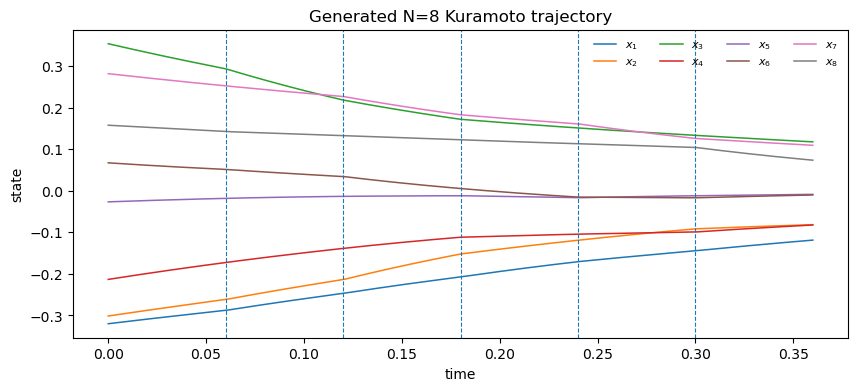

In [5]:

# ============================================================
# Cell 3 — Generate the trajectory
# ============================================================
n_total_intervals = N_STAGES * INTERVALS_PER_STAGE
T = np.arange(n_total_intervals + 1, dtype=float) * DT
X = np.empty((n_total_intervals + 1, N), dtype=float)
X[0] = X0

true_stage_of_interval = np.repeat(
    np.arange(N_STAGES, dtype=int), INTERVALS_PER_STAGE
)
for n, stage in enumerate(true_stage_of_interval):
    X[n + 1] = rk4_step(X[n], DT, int(stage))

t = T.copy()

state_displacement = np.linalg.norm(X[-1] - X[0])
max_abs_state = np.max(np.abs(X))
net_sum_change = float(X[-1].sum() - X[0].sum())

print("=" * 90)
print("Kuramoto trajectory generated")
print("=" * 90)
print("X shape                :", X.shape)
print("||X(T)-X(0)||          :", f"{state_displacement:.6e}")
print("max |x_i(t)|           :", f"{max_abs_state:.6e}")
print("sum_i x_i change       :", f"{net_sum_change:.6e}")
print("all finite             :", np.isfinite(X).all())

assert X.shape == (721, 8)
assert np.allclose(np.diff(t), DT)
assert np.isfinite(X).all()
assert abs(net_sum_change) < 1e-10

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(N):
    ax.plot(t, X[:, i], lw=1.1, label=f"$x_{i+1}$")
for tc in true_change_times:
    ax.axvline(tc, ls="--", lw=0.8)
ax.set_xlabel("time")
ax.set_ylabel("state")
ax.set_title("Generated N=8 Kuramoto trajectory")
ax.legend(ncol=4, fontsize=8, frameon=False)
plt.show()


STEP 1 — blind temporal segmentation
jump median       : 2.052779750772e-03
jump MAD          : 3.333185449132e-04
blind threshold   : 8.719150649037e-03
true indices      : [120 240 360 480 600]
detected indices  : [120 240 360 480 600]
detected times    : [0.06 0.12 0.18 0.24 0.3 ]


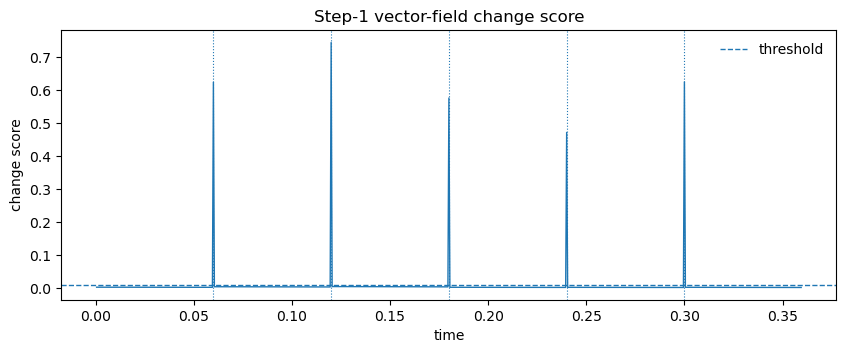

TIDES STEP 1: PASS


In [6]:

# ============================================================
# Cell 4 — Candidate-edge incidence matrix and blind Step-1 threshold
# ============================================================
M = len(CANDIDATE_EDGES)
D = np.zeros((N, M), dtype=float)
for m, (i, j) in enumerate(CANDIDATE_EDGES):
    D[i - 1, m] = -1.0
    D[j - 1, m] = +1.0

# Same fully blind robust threshold used in the earlier notebook.
V_SECANT = np.diff(X, axis=0) / DT
jump = np.linalg.norm(V_SECANT[1:] - V_SECANT[:-1], axis=1)
jump_median = float(np.median(jump))
jump_mad = float(np.median(np.abs(jump - jump_median)))
blind_threshold = jump_median + 20.0 * jump_mad

s1_check = tides.detect_changes(
    X,
    t,
    method="secant",
    threshold=blind_threshold,
    min_separation=1,
)

print("=" * 90)
print("STEP 1 — blind temporal segmentation")
print("=" * 90)
print("jump median       :", f"{jump_median:.12e}")
print("jump MAD          :", f"{jump_mad:.12e}")
print("blind threshold   :", f"{blind_threshold:.12e}")
print("true indices      :", true_transition_indices)
print("detected indices  :", s1_check.transition_indices)
print("detected times    :", s1_check.transition_times)

assert np.array_equal(s1_check.transition_indices, true_transition_indices)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(s1_check.score_times, s1_check.scores, lw=1.0)
ax.axhline(blind_threshold, ls="--", lw=1.0, label="threshold")
for tc in true_change_times:
    ax.axvline(tc, ls=":", lw=0.8)
ax.set_xlabel("time")
ax.set_ylabel("change score")
ax.set_title("Step-1 vector-field change score")
ax.legend(frameon=False)
plt.show()

print("TIDES STEP 1: PASS")



## Fully blind three-layer run

The next cell is the main integration test. It uses only \(X(t)\), \(t\), the complete candidate-edge incidence matrix \(D\), and a degree-11 relative-coordinate polynomial library.

No true edge support, edge weights, or sinusoidal law are passed to inference.

For this first blind run, Step 3 performs:

- global shared-law basin discovery under \(H_{\rm FD}\);
- finite-precision feasibility profiling and MDL accounting;

but sets `max_sweeps=0`, so it **does not yet perform the expensive structural add/drop/swap compression**. This isolates the correctness of the complete new data path before testing MDL compression separately.


In [7]:

# ============================================================
# Cell 5 — Fully blind end-to-end TIDES run
# ============================================================
POLY_DEGREE = 11

t0 = time.perf_counter()

BLIND = tides.run_tides(
    X,
    t,
    D,
    step1_kwargs={
        "method": "secant",
        "threshold": blind_threshold,
        "min_separation": 1,
    },
    preprocessing_method="four_point_midpoint",
    resolution_audit=True,
    uncertainty_multiplier=20.0,
    library_mode="relative_polynomial",
    library_degree=POLY_DEGREE,
    check_sampled_swap_equivariance=True,
    step2_kwargs={
        "design_mode": "dense",
        "solver_method": "dense_lstsq",
    },
    physical_hypothesis="fixed_dynamics",
    step3_kwargs={
        "quantizer_bound": 8.0,
        "n_basin_hops": 10,
        "basin_seed": 20260916,
        "basin_local_max_nfev": 50,
        "max_sweeps": 0,             # feasibility discovery only in the blind run
        "q_min": 1,
        "q_max": 64,
        "max_nfev": 100,
        "max_coordinate_passes": 2,
    },
)

blind_elapsed = time.perf_counter() - t0

print("=" * 90)
print("FULL THREE-LAYER BLIND RUN")
print("=" * 90)
print("elapsed / s                  :", f"{blind_elapsed:.3f}")
print("transition indices           :", BLIND.transition_indices)
print("preprocessing observations   :", BLIND.preprocessing.n_observations)
print("samples / stage              :", BLIND.preprocessing.samples_per_stage.tolist())
print("uncertainty floor            :", f"{BLIND.uncertainty_floor:.12e}")
print("Step-2 minimum residual      :", f"{BLIND.step2.minimum_relative_residual:.12e}")
print("Step-2 family empty?         :", BLIND.step2.is_empty)
print("Step-3 feasible              :", BLIND.step3.feasible)
print("Step-3 finite residual       :", f"{BLIND.step3.relative_residual:.12e}")
print("Step-3 continuous residual   :", f"{BLIND.step3.continuous_relative_residual:.12e}")
print("Step-3 q upper bound         :", BLIND.step3.q_upper)
print("blind basin hops             :", BLIND.step3.search_result.basin_search.n_hops)
print("blind accepted basin hops    :", BLIND.step3.search_result.basin_search.n_accepted)

assert np.array_equal(BLIND.transition_indices, true_transition_indices)
assert BLIND.preprocessing.n_observations == 708
assert np.array_equal(BLIND.preprocessing.samples_per_stage, np.array([118] * 6))
assert not BLIND.step2.is_empty
assert BLIND.step3 is not None and BLIND.step3.feasible

print("\nEND-TO-END THREE-LAYER PIPELINE: PASS")


FULL THREE-LAYER BLIND RUN
elapsed / s                  : 12.219
transition indices           : [120 240 360 480 600]
preprocessing observations   : 708
samples / stage              : [118, 118, 118, 118, 118, 118]
uncertainty floor            : 1.038205007128e-11
Step-2 minimum residual      : 9.672799464898e-14
Step-2 family empty?         : False
Step-3 feasible              : True
Step-3 finite residual       : 7.159548749971e-12
Step-3 continuous residual   : 6.906032557015e-14
Step-3 q upper bound         : 39
blind basin hops             : 1
blind accepted basin hops    : 1

END-TO-END THREE-LAYER PIPELINE: PASS


In [8]:

# ============================================================
# Cell 6 — Preprocessing and library audit
# ============================================================
prep = BLIND.preprocessing
LOCAL_LIBRARY = BLIND.interaction_library
FAMILY = BLIND.field_family

DIFF_SCALE = float(LOCAL_LIBRARY.metadata["atom_metadata"][0]["difference_scale"])
L = LOCAL_LIBRARY.n_features

THETA_TAYLOR_GAUGE = np.zeros(L, dtype=float)
for p in range(1, L + 1):
    if p % 2 == 1:
        k = (p - 1) // 2
        THETA_TAYLOR_GAUGE[p - 1] = (
            ((-1.0) ** k) * DIFF_SCALE ** (p - 1) / math.factorial(p)
        )

tail = np.array([i - 1 for i, _ in CANDIDATE_EDGES], dtype=int)
head = np.array([j - 1 for _, j in CANDIDATE_EDGES], dtype=int)
d_all = (prep.x_mid[:, head] - prep.x_mid[:, tail]).ravel()
z_all = d_all / DIFF_SCALE

f_taylor_phys = DIFF_SCALE * sum(
    THETA_TAYLOR_GAUGE[p - 1] * z_all**p
    for p in range(1, L + 1)
)
f_true = np.sin(d_all)
taylor_rel_error = np.linalg.norm(f_taylor_phys - f_true) / np.linalg.norm(f_true)

print("=" * 90)
print("PREPROCESSING + INTERACTION LIBRARY")
print("=" * 90)
print("midpoint state shape          :", prep.x_mid.shape)
print("midpoint derivative shape     :", prep.velocity_mid.shape)
print("resolution relative max       :", f"{prep.resolution_relative_max:.12e}")
print("estimated uncertainty floor   :", f"{prep.estimated_uncertainty_floor:.12e}")
print("library mode                  :", LOCAL_LIBRARY.mode)
print("library feature shape         :", LOCAL_LIBRARY.endpoint_features.shape)
print("feature labels                :", LOCAL_LIBRARY.feature_labels)
print("difference scale s            :", f"{DIFF_SCALE:.12e}")
print("Taylor gauge theta            :", np.array2string(THETA_TAYLOR_GAUGE, precision=12))
print("degree-11 Taylor law rel.err  :", f"{taylor_rel_error:.12e}")

assert prep.x_mid.shape == (708, 8)
assert LOCAL_LIBRARY.endpoint_features.shape == (708, 28, 11, 2)
assert np.isclose(THETA_TAYLOR_GAUGE[0], 1.0)


PREPROCESSING + INTERACTION LIBRARY
midpoint state shape          : (708, 8)
midpoint derivative shape     : (708, 8)
resolution relative max       : 5.191025035641e-13
estimated uncertainty floor   : 1.038205007128e-11
library mode                  : candidate
library feature shape         : (708, 28, 11, 2)
feature labels                : ('rel_d^1', 'rel_d^2', 'rel_d^3', 'rel_d^4', 'rel_d^5', 'rel_d^6', 'rel_d^7', 'rel_d^8', 'rel_d^9', 'rel_d^10', 'rel_d^11')
difference scale s            : 6.728386482590e-01
Taylor gauge theta            : [ 1.000000000000e+00  0.000000000000e+00 -7.545197443182e-02
  0.000000000000e+00  1.707900133698e-03  0.000000000000e+00
 -1.840920531713e-05  0.000000000000e+00  1.157509074082e-07
  0.000000000000e+00 -4.763800639758e-10]
degree-11 Taylor law rel.err  : 1.965207567737e-13


STEP 2 — EDGE-SPACE FIELD FAMILY
reference B shape         : (6, 28, 11)
parameter count           : 1848
rank                      : 498
nullity                   : 1350
minimum relative residual : 9.672799464898e-14
uncertainty floor         : 1.038205007128e-11
slack^2                   : 1.487993096492e-19
stage ranks               : [80, 83, 87, 84, 81, 83]
stage nullities           : [228, 225, 221, 224, 227, 225]

Alternative family member
||B_alt - B_ref||        : 3.371198433129e+11
rho(B_alt)               : 8.825448417239e-12
feasible                  : True


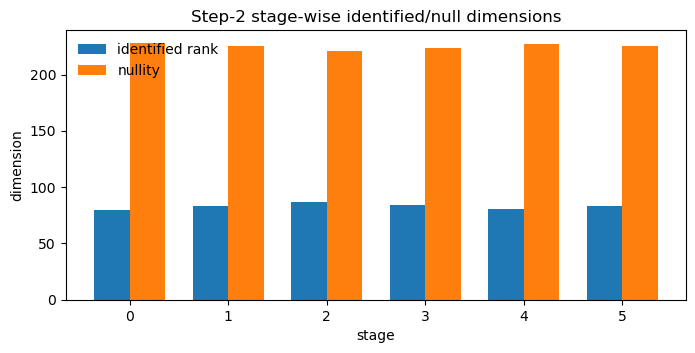

In [9]:

# ============================================================
# Cell 7 — Step 2: observational edge-space family B_epsilon
# ============================================================
print("=" * 90)
print("STEP 2 — EDGE-SPACE FIELD FAMILY")
print("=" * 90)
print("reference B shape         :", FAMILY.reference_B_stages.shape)
print("parameter count           :", FAMILY.parameter_count)
print("rank                      :", FAMILY.rank)
print("nullity                   :", FAMILY.nullity)
print("minimum relative residual :", f"{FAMILY.minimum_relative_residual:.12e}")
print("uncertainty floor         :", f"{FAMILY.uncertainty_floor:.12e}")
print("slack^2                   :", f"{FAMILY.slack_squared:.12e}")

stage_ranks = [g.rank for g in FAMILY.stage_geometry]
stage_nullities = [g.nullity for g in FAMILY.stage_geometry]
print("stage ranks               :", stage_ranks)
print("stage nullities           :", stage_nullities)

assert FAMILY.reference_B_stages.shape == (6, 28, 11)
assert FAMILY.parameter_count == 6 * 28 * 11
assert FAMILY.rank is not None and FAMILY.nullity is not None
assert FAMILY.rank + FAMILY.nullity == FAMILY.parameter_count
assert FAMILY.minimum_relative_residual <= FAMILY.uncertainty_floor

# Explicitly exhibit another member of the same observational family.
B_ALT = FAMILY.sample_feasible(
    rng=np.random.default_rng(20260916),
    null_scale=1.0,
    boundary_fraction=0.85,
)
rho_alt = FAMILY.relative_residual(B_ALT)
distance_alt = np.linalg.norm(B_ALT - FAMILY.reference_B_stages)

print("\nAlternative family member")
print("||B_alt - B_ref||        :", f"{distance_alt:.12e}")
print("rho(B_alt)               :", f"{rho_alt:.12e}")
print("feasible                  :", FAMILY.is_feasible(B_ALT))

assert FAMILY.is_feasible(B_ALT)

fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(N_STAGES)
ax.bar(x - 0.18, stage_ranks, width=0.36, label="identified rank")
ax.bar(x + 0.18, stage_nullities, width=0.36, label="nullity")
ax.set_xlabel("stage")
ax.set_ylabel("dimension")
ax.set_title("Step-2 stage-wise identified/null dimensions")
ax.legend(frameon=False)
plt.show()


STEP 3 — BLIND H_FD BASIN
structural groups retained  : 168
active polynomial atoms     : (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10)
continuous theta            : [ 1.000000000000e+00  2.265262829215e-14 -7.545197434488e-02
 -3.087528603558e-13  1.707899806671e-03  9.938980592207e-13
 -1.840876230251e-05 -1.037627988988e-12  1.154448129595e-07
  3.041186478164e-13 -3.848974041202e-10]
Taylor reference            : [ 1.000000000000e+00  0.000000000000e+00 -7.545197443182e-02
  0.000000000000e+00  1.707900133698e-03  0.000000000000e+00
 -1.840920531713e-05  0.000000000000e+00  1.157509074082e-07
  0.000000000000e+00 -4.763800639758e-10]
theta / Taylor rel.err      : 6.406988966441e-10
continuous residual         : 6.906032557015e-14
finite-precision residual   : 7.159548749971e-12
q upper bound               : 39
precision certified exact?  : False
MDL total / bits            : 6988.067
  structural / bits         : 29.148
  expression / bits         : 6.919
  precision / bits          : 6952.00

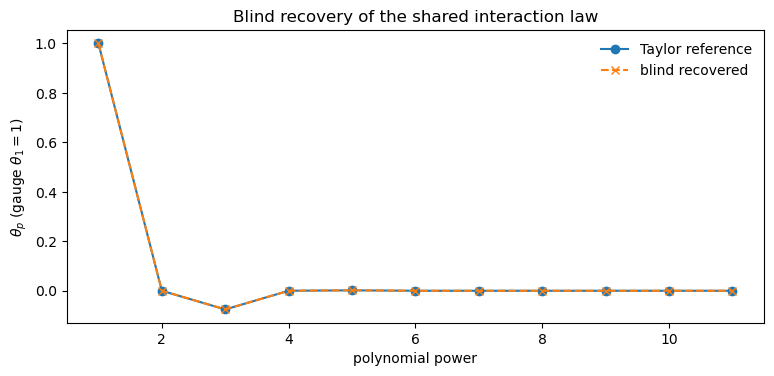

In [10]:

# ============================================================
# Cell 8 — Blind H_FD shared-law recovery before structural compression
# ============================================================
BLIND_PHYS = BLIND.step3

theta_blind_cont = np.asarray(BLIND_PHYS.continuous_theta, dtype=float)
theta_blind_rel = (
    np.linalg.norm(theta_blind_cont - THETA_TAYLOR_GAUGE)
    / np.linalg.norm(THETA_TAYLOR_GAUGE)
)

print("=" * 90)
print("STEP 3 — BLIND H_FD BASIN")
print("=" * 90)
print("structural groups retained  :", len(BLIND_PHYS.search_result.best_state.active_groups))
print("active polynomial atoms     :", BLIND_PHYS.active_atoms)
print("continuous theta            :", np.array2string(theta_blind_cont, precision=12))
print("Taylor reference            :", np.array2string(THETA_TAYLOR_GAUGE, precision=12))
print("theta / Taylor rel.err      :", f"{theta_blind_rel:.12e}")
print("continuous residual         :", f"{BLIND_PHYS.continuous_relative_residual:.12e}")
print("finite-precision residual   :", f"{BLIND_PHYS.relative_residual:.12e}")
print("q upper bound               :", BLIND_PHYS.q_upper)
print("precision certified exact?  :", BLIND_PHYS.precision_certified_exact)
print("MDL total / bits            :", f"{BLIND_PHYS.mdl_score.total_bits:.3f}")
print("  structural / bits         :", f"{BLIND_PHYS.mdl_score.structural_bits:.3f}")
print("  expression / bits         :", f"{BLIND_PHYS.mdl_score.expression_bits:.3f}")
print("  precision / bits          :", f"{BLIND_PHYS.mdl_score.precision_bits:.3f}")

# The structural representation is deliberately still dense here because
# max_sweeps=0.  Nevertheless the shared law is inferred from the trajectory.
assert theta_blind_rel < 1e-6
assert BLIND_PHYS.feasible

powers = np.arange(1, L + 1)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(powers, THETA_TAYLOR_GAUGE, "o-", label="Taylor reference")
ax.plot(powers, theta_blind_cont, "x--", label="blind recovered")
ax.set_xlabel("polynomial power")
ax.set_ylabel(r"$\theta_p$ (gauge $\theta_1=1$)")
ax.set_title("Blind recovery of the shared interaction law")
ax.legend(frameon=False)
plt.show()



## Oracle structural-support control for MDL expression compression

The next control uses the true support of \(W^{(1)}\) and the true supports of \(\Delta W^{(k)}\) **only as an initialization constraint**. It does **not** provide the edge weights or the sine law.

Its purpose is narrow: isolate the final-stage question

\[
\text{given the correct structural sector, does MDL compress the polynomial law correctly?}
\]

This mirrors the oracle-support controls in the earlier N=8 notebook while using the new Step-3 factorization/MDL machinery.


In [11]:

# ============================================================
# Cell 9 — Build oracle structural group labels
# ============================================================
TRUE_BASELINE_GROUPS = tuple(
    ("baseline", EDGE_INDEX_1B[edge])
    for edge in SNAPSHOTS[0]
)

TRUE_CHANGE_GROUPS = tuple(
    ("transition", k, EDGE_INDEX_1B[edge])
    for k, support in enumerate(transition_supports_true)
    for edge in support
)

TRUE_PHYSICAL_GROUPS = TRUE_BASELINE_GROUPS + TRUE_CHANGE_GROUPS

print("=" * 90)
print("ORACLE STRUCTURAL CONTROL")
print("=" * 90)
print("baseline groups       :", len(TRUE_BASELINE_GROUPS))
print("transition groups     :", len(TRUE_CHANGE_GROUPS))
print("total physical groups :", len(TRUE_PHYSICAL_GROUPS))

assert len(TRUE_BASELINE_GROUPS) == 10
assert len(TRUE_CHANGE_GROUPS) == 20
assert len(TRUE_PHYSICAL_GROUPS) == 30


ORACLE STRUCTURAL CONTROL
baseline groups       : 10
transition groups     : 20
total physical groups : 30


In [12]:

# ============================================================
# Cell 10 — New Step 3 + MDL expression compression
# ============================================================
# Structural moves are disabled in this oracle-support control.
# MDL is allowed to compress only the shared polynomial expression.
# One atom proposal is evaluated per sweep; six sweeps are enough for
# this benchmark to expose the odd low-order sine structure.

t0 = time.perf_counter()

ORACLE_MDL = step3pc.compress_fixed_dynamics(
    FAMILY,
    quantizer_bound=8.0,
    initial_groups=TRUE_PHYSICAL_GROUPS,
    initial_atoms=tuple(range(L)),
    n_basin_hops=0,
    basin_seed=20260916,
    basin_local_max_nfev=60,
    max_sweeps=6,
    q_min=1,
    q_max=64,
    max_nfev=80,
    max_coordinate_passes=1,
    top_group_drops=0,
    top_group_adds=0,
    top_group_swaps=0,
    top_atom_drops=1,
    top_atom_adds=0,
    top_atom_swaps=0,
)

oracle_elapsed = time.perf_counter() - t0

print("=" * 90)
print("ORACLE-SUPPORT MDL COMPRESSION")
print("=" * 90)
print("elapsed / s               :", f"{oracle_elapsed:.3f}")
print("feasible                   :", ORACLE_MDL.feasible)
print("continuous residual        :", f"{ORACLE_MDL.continuous_relative_residual:.12e}")
print("finite residual            :", f"{ORACLE_MDL.relative_residual:.12e}")
print("uncertainty floor          :", f"{ORACLE_MDL.uncertainty_floor:.12e}")
print("active atom indices        :", ORACLE_MDL.active_atoms)
print("active polynomial powers   :", tuple(a + 1 for a in ORACLE_MDL.active_atoms))
print("q upper bound              :", ORACLE_MDL.q_upper)
print("MDL total / bits           :", f"{ORACLE_MDL.mdl_score.total_bits:.3f}")

print("\nAccepted MDL moves:")
for h in ORACLE_MDL.search_result.history:
    print(
        f"  sweep {h.sweep:02d}: {h.move.label():>18s} | "
        f"{h.old_mdl_upper / np.log(2):.3f} -> "
        f"{h.new_mdl_upper / np.log(2):.3f} bits"
    )

assert ORACLE_MDL.feasible
assert 0 in ORACLE_MDL.active_atoms
assert all((a + 1) % 2 == 1 for a in ORACLE_MDL.active_atoms)


ORACLE-SUPPORT MDL COMPRESSION
elapsed / s               : 4.609
feasible                   : True
continuous residual        : 2.128543589884e-13
finite residual            : 9.168276319126e-12
uncertainty floor          : 1.038205007128e-11
active atom indices        : (0, 2, 4, 6, 8)
active polynomial powers   : (1, 3, 5, 7, 9)
q upper bound              : 39
MDL total / bits           : 1473.160

Accepted MDL moves:
  sweep 00:       drop_atom(1) | 1701.320 -> 1665.642 bits
  sweep 01:       drop_atom(9) | 1665.642 -> 1628.812 bits
  sweep 02:       drop_atom(3) | 1628.812 -> 1591.227 bits
  sweep 03:       drop_atom(5) | 1591.227 -> 1553.034 bits
  sweep 04:       drop_atom(7) | 1553.034 -> 1514.298 bits
  sweep 05:      drop_atom(10) | 1514.298 -> 1473.160 bits


RECOVERY AUDIT
selected continuous theta  : [ 1.000000000000e+00  0.000000000000e+00 -7.545197436935e-02
  0.000000000000e+00  1.707899721238e-03  0.000000000000e+00
 -1.840813656155e-05  0.000000000000e+00  1.145593431455e-07
  0.000000000000e+00  0.000000000000e+00]
selected Taylor reference  : [ 1.000000000000e+00  0.000000000000e+00 -7.545197443182e-02
  0.000000000000e+00  1.707900133698e-03  0.000000000000e+00
 -1.840920531713e-05  0.000000000000e+00  1.157509074082e-07
  0.000000000000e+00  0.000000000000e+00]
theta rel.err               : 1.649422430236e-09
continuous W rel.err        : 3.132929561286e-12
finite-precision W rel.err  : 1.960451289122e-11
recovered law vs sin(d)     : 2.400879934542e-12


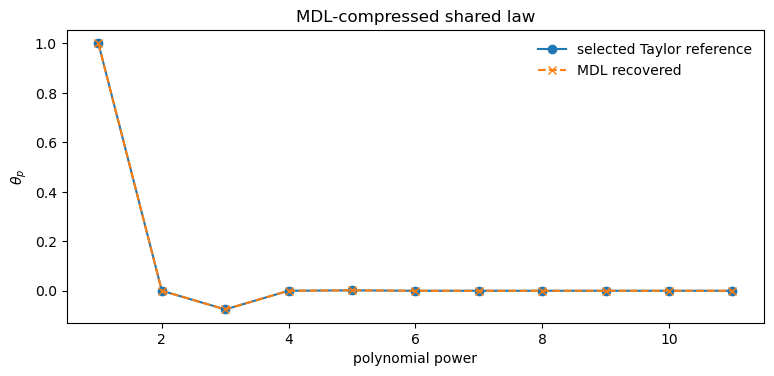

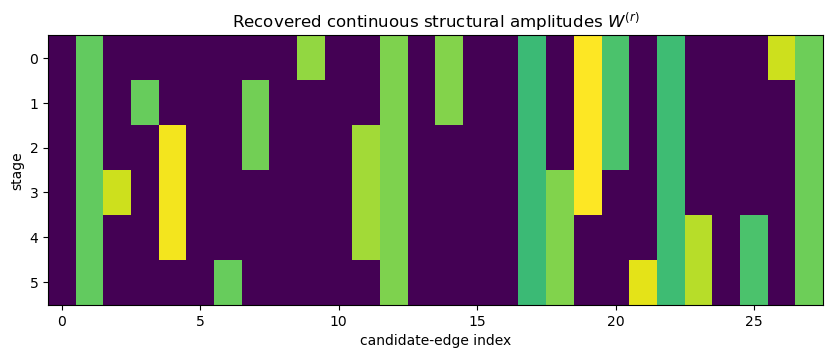

In [13]:

# ============================================================
# Cell 11 — Quantitative recovery audit
# ============================================================
theta_hat = np.asarray(ORACLE_MDL.continuous_theta, dtype=float)

theta_reference_selected = THETA_TAYLOR_GAUGE.copy()
inactive = [a for a in range(L) if a not in ORACLE_MDL.active_atoms]
theta_reference_selected[inactive] = 0.0

theta_rel_to_selected_taylor = (
    np.linalg.norm(theta_hat - theta_reference_selected)
    / np.linalg.norm(theta_reference_selected)
)

# In the gauge theta_1 = 1, the true structural amplitudes are s * w_ij.
W_TRUE_GAUGE = np.zeros((N_STAGES, M), dtype=float)
for r, snapshot in enumerate(SNAPSHOTS):
    for edge in snapshot:
        W_TRUE_GAUGE[r, EDGE_INDEX_1B[edge]] = DIFF_SCALE * EDGE_WEIGHT[edge]

active_mask = W_TRUE_GAUGE != 0.0
W_cont_rel = (
    np.linalg.norm(
        (ORACLE_MDL.continuous_W_stages - W_TRUE_GAUGE)[active_mask]
    )
    / np.linalg.norm(W_TRUE_GAUGE[active_mask])
)
W_finite_rel = (
    np.linalg.norm(
        (ORACLE_MDL.W_stages - W_TRUE_GAUGE)[active_mask]
    )
    / np.linalg.norm(W_TRUE_GAUGE[active_mask])
)

# Compare the recovered polynomial law directly with sin(d) on all sampled
# candidate-pair relative states.
f_hat = DIFF_SCALE * sum(
    theta_hat[p - 1] * z_all**p
    for p in range(1, L + 1)
)
law_rel_error = np.linalg.norm(f_hat - np.sin(d_all)) / np.linalg.norm(np.sin(d_all))

print("=" * 90)
print("RECOVERY AUDIT")
print("=" * 90)
print("selected continuous theta  :", np.array2string(theta_hat, precision=12))
print("selected Taylor reference  :", np.array2string(theta_reference_selected, precision=12))
print("theta rel.err               :", f"{theta_rel_to_selected_taylor:.12e}")
print("continuous W rel.err        :", f"{W_cont_rel:.12e}")
print("finite-precision W rel.err  :", f"{W_finite_rel:.12e}")
print("recovered law vs sin(d)     :", f"{law_rel_error:.12e}")

assert theta_rel_to_selected_taylor < 1e-6
assert W_cont_rel < 1e-7
assert law_rel_error < 1e-7

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(powers, theta_reference_selected, "o-", label="selected Taylor reference")
ax.plot(powers, theta_hat, "x--", label="MDL recovered")
ax.set_xlabel("polynomial power")
ax.set_ylabel(r"$\theta_p$")
ax.set_title("MDL-compressed shared law")
ax.legend(frameon=False)
plt.show()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.imshow(ORACLE_MDL.continuous_W_stages, aspect="auto")
ax.set_xlabel("candidate-edge index")
ax.set_ylabel("stage")
ax.set_title("Recovered continuous structural amplitudes $W^{(r)}$")
plt.show()


In [14]:

# ============================================================
# Cell 12 — Optional long blind structural MDL search
# ============================================================
# The current reference MDL search re-profiles the nonlinear shared-law
# factorization and finite precision for every shortlisted structural move.
# Starting from all 168 physical groups is therefore intentionally expensive.
#
# Keep this False for the one-pass benchmark smoke test.  Flip to True when
# you specifically want to study blind structural compression runtime/path.

RUN_LONG_BLIND_COMPRESSION = False

if RUN_LONG_BLIND_COMPRESSION:
    LONG_BLIND = step3pc.compress_fixed_dynamics(
        FAMILY,
        quantizer_bound=8.0,
        initial_groups=None,          # all baseline + transition edge groups
        initial_atoms=tuple(range(L)),
        n_basin_hops=10,
        basin_seed=20260916,
        basin_local_max_nfev=50,
        max_sweeps=160,
        q_min=1,
        q_max=64,
        max_nfev=100,
        max_coordinate_passes=2,
        top_group_drops=3,
        top_group_adds=1,
        top_group_swaps=1,
        top_atom_drops=2,
        top_atom_adds=1,
        top_atom_swaps=1,
    )
    print("final blind groups :", len(LONG_BLIND.search_result.best_state.active_groups))
    print("final blind atoms  :", LONG_BLIND.active_atoms)
    print("final blind rho    :", LONG_BLIND.relative_residual)
    print("final blind MDL    :", LONG_BLIND.mdl_score.total_bits, "bits")
else:
    print(
        "RUN_LONG_BLIND_COMPRESSION=False — skipped the deliberately expensive "
        "full structural MDL search."
    )


RUN_LONG_BLIND_COMPRESSION=False — skipped the deliberately expensive full structural MDL search.


In [15]:

# ============================================================
# Cell 13 — Summary
# ============================================================
print("=" * 90)
print("N=8 KURAMOTO / THREE-LAYER TIDES SUMMARY")
print("=" * 90)
print("Step 1 exact transitions           :", np.array_equal(BLIND.transition_indices, true_transition_indices))
print("midpoint observations              :", BLIND.preprocessing.n_observations)
print("uncertainty floor                  :", f"{BLIND.uncertainty_floor:.6e}")
print("Step 2 B shape                     :", FAMILY.reference_B_stages.shape)
print("Step 2 rank / nullity              :", FAMILY.rank, "/", FAMILY.nullity)
print("Step 2 minimum residual            :", f"{FAMILY.minimum_relative_residual:.6e}")
print("alternative family member feasible :", FAMILY.is_feasible(B_ALT))
print("blind H_FD basin feasible          :", BLIND_PHYS.feasible)
print("blind theta/Taylor rel.err         :", f"{theta_blind_rel:.6e}")
print("oracle-support MDL active powers   :", tuple(a + 1 for a in ORACLE_MDL.active_atoms))
print("oracle-support MDL residual        :", f"{ORACLE_MDL.relative_residual:.6e}")
print("oracle theta/Taylor rel.err        :", f"{theta_rel_to_selected_taylor:.6e}")
print("oracle W rel.err                   :", f"{W_cont_rel:.6e}")
print("recovered polynomial vs sin rel.err:", f"{law_rel_error:.6e}")
print()
print("Interpretation:")
print("  1. Step 2 reconstructs the observational family B_epsilon, not one privileged B.")
print("  2. A blind fixed-dynamics factorization finds the shared sine-like polynomial law.")
print("  3. With structure held fixed as a control, MDL removes unsupported polynomial terms")
print("     while remaining inside the same Step-2 uncertainty family.")
print("=" * 90)

assert BLIND_PHYS.feasible
assert ORACLE_MDL.feasible
print("THREE-LAYER N=8 BENCHMARK: PASS")


N=8 KURAMOTO / THREE-LAYER TIDES SUMMARY
Step 1 exact transitions           : True
midpoint observations              : 708
uncertainty floor                  : 1.038205e-11
Step 2 B shape                     : (6, 28, 11)
Step 2 rank / nullity              : 498 / 1350
Step 2 minimum residual            : 9.672799e-14
alternative family member feasible : True
blind H_FD basin feasible          : True
blind theta/Taylor rel.err         : 6.406989e-10
oracle-support MDL active powers   : (1, 3, 5, 7, 9)
oracle-support MDL residual        : 9.168276e-12
oracle theta/Taylor rel.err        : 1.649422e-09
oracle W rel.err                   : 3.132930e-12
recovered polynomial vs sin rel.err: 2.400880e-12

Interpretation:
  1. Step 2 reconstructs the observational family B_epsilon, not one privileged B.
  2. A blind fixed-dynamics factorization finds the shared sine-like polynomial law.
  3. With structure held fixed as a control, MDL removes unsupported polynomial terms
     while remaining 